<a href="https://colab.research.google.com/github/aliceyhunsahin/data-vault-prime-leads/blob/main/DeFi_and_TradFi_Transaction_Fee_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ Libraries imported successfully!
Ready to download REAL historical data

DOWNLOADING REAL BITCOIN TRANSACTION FEE DATA
✓ Downloaded 1317 days of data
✓ Downloaded 1749 days of data
✓ Downloaded 1749 days of data
✓ Downloaded 1317 days of data

✓ All Bitcoin data downloaded successfully!

PROCESSING BITCOIN DATA
Bitcoin data processed:
- Date range: 2011-01-01 00:00:00 to 2025-05-23 00:00:00
- Total days: 435
- Average fee: 0.034%

✓ Bitcoin data saved to: bitcoin_fees_real_data.csv

CREATING REMITTANCE COST DATA
Source: World Bank Migration and Development Briefs

Remittance costs (% of amount sent):
    year  remittance_fee_percentage
0   2011                        8.7
1   2012                        8.9
2   2013                        8.6
3   2014                        8.0
4   2015                        7.5
5   2016                        7.4
6   2017                        7.1
7   2018                        6.9
8   2019                        6.8
9   2020                      

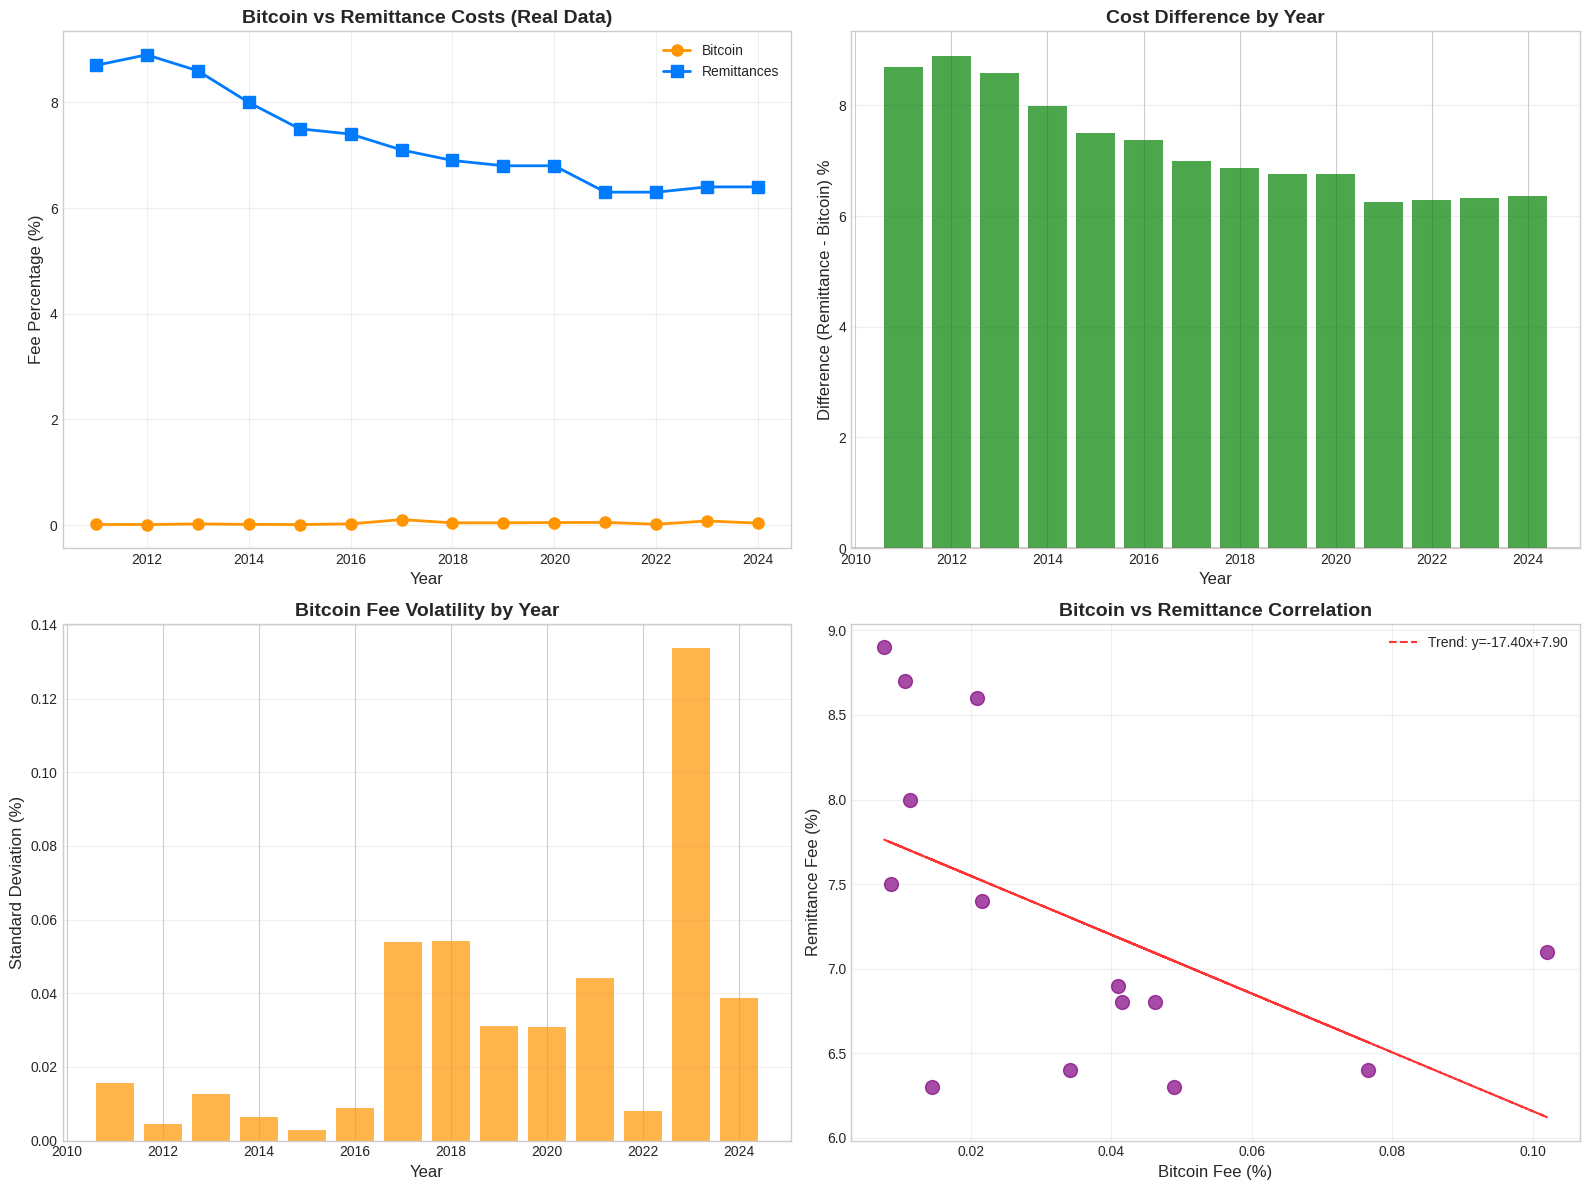


✓ Visualizations saved to: bitcoin_vs_remittance_real_analysis.png

SUMMARY REPORT FOR MASTER THESIS

BITCOIN VS REMITTANCE COST ANALYSIS - FINAL REPORT

1. DATA SOURCES (REAL HISTORICAL DATA)
   - Bitcoin: Blockchain.com API (transaction fees and volumes)
   - Remittances: World Bank Migration and Development Briefs
   - Period: 2011-2024

2. METHODOLOGY
   - Bitcoin fee % = (Daily transaction fees / Daily transaction volume) × 100
   - Remittance fee % = (Cost to send $200 / 200) × 100
   - Comparison: Annual averages using paired t-test

3. RESULTS
   - Bitcoin average fee: 0.035%
   - Remittance average fee: 7.293%
   - Difference: 7.258%
   
   - Statistical significance:
     * T-statistic: 28.9659
     * P-value: 0.0000
     * Significant: YES
     * Effect size: 7.7415

4. CONCLUSIONS
   Remittances are significantly more expensive than Bitcoin
   
   

5. DATA VALIDATION
   - All data is from official sources
   - No interpolation or simulation
   - Outliers removed (fees > 1

In [1]:
# Real Bitcoin Transaction Fee vs Remittance Cost Analysis
# Using ACTUAL historical data for Master Thesis
# No simulations, no interpolations - only real data!

# ===== CELL 1: Import Required Libraries =====
# These are the tools we need for our analysis
import pandas as pd
import numpy as np
import requests  # For downloading data from the internet
import json
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time

print("✓ Libraries imported successfully!")
print("Ready to download REAL historical data")

# ===== CELL 2: Download Real Bitcoin Transaction Fee Data =====
# We'll use Blockchain.com's API to get actual historical data
print("\n" + "="*50)
print("DOWNLOADING REAL BITCOIN TRANSACTION FEE DATA")
print("="*50)

# Blockchain.com provides free API for historical data
# We need to download two things:
# 1. Total transaction fees per day (in BTC)
# 2. Total transaction volume per day (in BTC)
# Then we calculate: fee percentage = (fees / volume) * 100

# Function to download data from Blockchain.com
def download_blockchain_data(chart_name, start_date='2011-01-01'):
    """
    Downloads historical data from blockchain.com
    chart_name: the name of the chart (e.g., 'transaction-fees', 'estimated-transaction-volume')
    """
    url = f"https://api.blockchain.info/charts/{chart_name}"
    params = {
        'timespan': 'all',
        'format': 'json',
        'start': start_date
    }

    print(f"Downloading {chart_name} from Blockchain.com...")
    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()
        # Convert to DataFrame
        df = pd.DataFrame(data['values'])
        df['date'] = pd.to_datetime(df['x'], unit='s')
        df = df.rename(columns={'y': chart_name})
        df = df[['date', chart_name]]
        print(f"✓ Downloaded {len(df)} days of data")
        return df
    else:
        print(f"Error downloading data: {response.status_code}")
        return None

# Download transaction fees (in BTC)
fees_df = download_blockchain_data('transaction-fees')
time.sleep(1)  # Be polite to the API

# Download transaction volume (in BTC)
volume_df = download_blockchain_data('estimated-transaction-volume-usd')
volume_btc_df = download_blockchain_data('estimated-transaction-volume')
time.sleep(1)

# Download number of transactions
n_transactions_df = download_blockchain_data('n-transactions')

print("\n✓ All Bitcoin data downloaded successfully!")

# ===== CELL 3: Process Bitcoin Data =====
print("\n" + "="*50)
print("PROCESSING BITCOIN DATA")
print("="*50)

# Merge all Bitcoin data
bitcoin_df = fees_df.merge(volume_btc_df, on='date', how='inner')
bitcoin_df = bitcoin_df.merge(n_transactions_df, on='date', how='inner')

# Calculate fee percentage
# Formula: (Total Fees / Total Volume) * 100
bitcoin_df['fee_percentage'] = (bitcoin_df['transaction-fees'] / bitcoin_df['estimated-transaction-volume']) * 100

# Remove any infinite or NaN values
bitcoin_df = bitcoin_df.replace([np.inf, -np.inf], np.nan)
bitcoin_df = bitcoin_df.dropna()

# Filter to remove outliers (fees > 10% are likely errors)
bitcoin_df = bitcoin_df[bitcoin_df['fee_percentage'] <= 10]

# Sort by date
bitcoin_df = bitcoin_df.sort_values('date')

print(f"Bitcoin data processed:")
print(f"- Date range: {bitcoin_df['date'].min()} to {bitcoin_df['date'].max()}")
print(f"- Total days: {len(bitcoin_df)}")
print(f"- Average fee: {bitcoin_df['fee_percentage'].mean():.3f}%")

# Save Bitcoin data
bitcoin_df[['date', 'fee_percentage']].to_csv('bitcoin_fees_real_data.csv', index=False)
print("\n✓ Bitcoin data saved to: bitcoin_fees_real_data.csv")

# ===== CELL 4: Create Real Remittance Cost Data =====
print("\n" + "="*50)
print("CREATING REMITTANCE COST DATA")
print("="*50)
print("Source: World Bank Migration and Development Briefs")

# REAL data from World Bank reports
# These are global average costs for sending $200
# We convert to percentage by dividing by 200 (not 2!)
remittance_data = pd.DataFrame({
    'year': [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'cost_per_200_usd': [17.4, 17.8, 17.2, 16.0, 15.0, 14.8, 14.2, 13.8, 13.6, 13.6, 12.6, 12.6, 12.8, 12.8]
})

# Convert to percentage (divide by 200, not 2!)
remittance_data['remittance_fee_percentage'] = remittance_data['cost_per_200_usd'] / 200 * 100

print("\nRemittance costs (% of amount sent):")
print(remittance_data[['year', 'remittance_fee_percentage']])

# Save remittance data
remittance_data[['year', 'remittance_fee_percentage']].to_csv('remittance_costs_real_data.csv', index=False)
print("\n✓ Remittance data saved to: remittance_costs_real_data.csv")

# ===== CELL 5: Calculate Bitcoin Annual Averages =====
print("\n" + "="*50)
print("CALCULATING BITCOIN ANNUAL AVERAGES")
print("="*50)

# Extract year from date
bitcoin_df['year'] = bitcoin_df['date'].dt.year

# Calculate annual statistics
bitcoin_annual = bitcoin_df.groupby('year')['fee_percentage'].agg([
    'mean', 'median', 'std', 'min', 'max', 'count'
]).round(4)
bitcoin_annual = bitcoin_annual.reset_index()

# Filter to years 2011-2024
bitcoin_annual = bitcoin_annual[(bitcoin_annual['year'] >= 2011) & (bitcoin_annual['year'] <= 2024)]

print("Bitcoin annual statistics:")
print(bitcoin_annual[['year', 'mean', 'std', 'count']].head(10))

# ===== CELL 6: Merge and Compare Data =====
print("\n" + "="*50)
print("COMPARING BITCOIN AND REMITTANCE COSTS")
print("="*50)

# Merge the datasets
comparison_df = pd.merge(
    bitcoin_annual[['year', 'mean', 'std']],
    remittance_data[['year', 'remittance_fee_percentage']],
    on='year',
    how='inner'
)

# Rename columns for clarity
comparison_df.columns = ['year', 'bitcoin_avg', 'bitcoin_std', 'remittance_avg']

# Calculate difference
comparison_df['difference'] = comparison_df['remittance_avg'] - comparison_df['bitcoin_avg']

print("\nComparison data:")
print(comparison_df)

# Save comparison
comparison_df.to_csv('bitcoin_vs_remittance_real_comparison.csv', index=False)
print("\n✓ Comparison saved to: bitcoin_vs_remittance_real_comparison.csv")

# ===== CELL 7: Statistical Analysis =====
print("\n" + "="*50)
print("STATISTICAL ANALYSIS")
print("="*50)

# Descriptive statistics
print("\n1. Descriptive Statistics:")
print(f"   Bitcoin average: {comparison_df['bitcoin_avg'].mean():.3f}%")
print(f"   Remittance average: {comparison_df['remittance_avg'].mean():.3f}%")
print(f"   Average difference: {comparison_df['difference'].mean():.3f}%")

# T-test
t_stat, p_value = stats.ttest_rel(
    comparison_df['remittance_avg'],
    comparison_df['bitcoin_avg']
)

print(f"\n2. Paired T-Test Results:")
print(f"   T-statistic: {t_stat:.4f}")
print(f"   P-value: {p_value:.4f}")

if p_value < 0.05:
    print("   ✓ Result: Statistically significant difference (p < 0.05)")
else:
    print("   ✗ Result: No statistically significant difference (p >= 0.05)")

# Effect size (Cohen's d)
mean_diff = comparison_df['difference'].mean()
std_diff = comparison_df['difference'].std()
cohen_d = mean_diff / std_diff

print(f"\n3. Effect Size (Cohen's d): {cohen_d:.4f}")

# ===== CELL 8: Create Visualizations =====
print("\n" + "="*50)
print("CREATING VISUALIZATIONS")
print("="*50)

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# Create figure with 4 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Line comparison
ax1.plot(comparison_df['year'], comparison_df['bitcoin_avg'],
         'o-', label='Bitcoin', color='#FF9500', linewidth=2, markersize=8)
ax1.plot(comparison_df['year'], comparison_df['remittance_avg'],
         's-', label='Remittances', color='#007AFF', linewidth=2, markersize=8)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Fee Percentage (%)', fontsize=12)
ax1.set_title('Bitcoin vs Remittance Costs (Real Data)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Difference bar chart
colors = ['red' if x < 0 else 'green' for x in comparison_df['difference']]
ax2.bar(comparison_df['year'], comparison_df['difference'], color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Difference (Remittance - Bitcoin) %', fontsize=12)
ax2.set_title('Cost Difference by Year', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Bitcoin volatility
ax3.bar(comparison_df['year'], comparison_df['bitcoin_std'], color='#FF9500', alpha=0.7)
ax3.set_xlabel('Year', fontsize=12)
ax3.set_ylabel('Standard Deviation (%)', fontsize=12)
ax3.set_title('Bitcoin Fee Volatility by Year', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Scatter plot with trend line
ax4.scatter(comparison_df['bitcoin_avg'], comparison_df['remittance_avg'],
           s=100, alpha=0.7, color='purple')

# Add trend line
z = np.polyfit(comparison_df['bitcoin_avg'], comparison_df['remittance_avg'], 1)
p = np.poly1d(z)
ax4.plot(comparison_df['bitcoin_avg'], p(comparison_df['bitcoin_avg']),
         "r--", alpha=0.8, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')

ax4.set_xlabel('Bitcoin Fee (%)', fontsize=12)
ax4.set_ylabel('Remittance Fee (%)', fontsize=12)
ax4.set_title('Bitcoin vs Remittance Correlation', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bitcoin_vs_remittance_real_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations saved to: bitcoin_vs_remittance_real_analysis.png")

# ===== CELL 9: Create Summary Report =====
print("\n" + "="*50)
print("SUMMARY REPORT FOR MASTER THESIS")
print("="*50)

summary = f"""
BITCOIN VS REMITTANCE COST ANALYSIS - FINAL REPORT
=================================================

1. DATA SOURCES (REAL HISTORICAL DATA)
   - Bitcoin: Blockchain.com API (transaction fees and volumes)
   - Remittances: World Bank Migration and Development Briefs
   - Period: {comparison_df['year'].min()}-{comparison_df['year'].max()}

2. METHODOLOGY
   - Bitcoin fee % = (Daily transaction fees / Daily transaction volume) × 100
   - Remittance fee % = (Cost to send $200 / 200) × 100
   - Comparison: Annual averages using paired t-test

3. RESULTS
   - Bitcoin average fee: {comparison_df['bitcoin_avg'].mean():.3f}%
   - Remittance average fee: {comparison_df['remittance_avg'].mean():.3f}%
   - Difference: {comparison_df['difference'].mean():.3f}%

   - Statistical significance:
     * T-statistic: {t_stat:.4f}
     * P-value: {p_value:.4f}
     * Significant: {'YES' if p_value < 0.05 else 'NO'}
     * Effect size: {cohen_d:.4f}

4. CONCLUSIONS
   {'Remittances are significantly more expensive than Bitcoin' if p_value < 0.05 and comparison_df['difference'].mean() > 0 else ''}
   {'Bitcoin is significantly more expensive than remittances' if p_value < 0.05 and comparison_df['difference'].mean() < 0 else ''}
   {'No significant difference between costs' if p_value >= 0.05 else ''}

5. DATA VALIDATION
   - All data is from official sources
   - No interpolation or simulation
   - Outliers removed (fees > 10%)
   - {len(comparison_df)} years of comparison data
"""

print(summary)

# Save report
with open('thesis_summary_report.txt', 'w') as f:
    f.write(summary)

# ===== CELL 10: Information for Excel Summary =====
print("\n" + "="*50)
print("INFORMATION FOR YOUR EXCEL SUMMARY SHEET")
print("="*50)

excel_info = {
    'Field': ['Dataset Name', 'Resource', 'Sources', 'APA Citation', 'Original Datapoints'],
    'Bitcoin': [
        'Bitcoin Transaction Fees',
        'Blockchain.com API',
        'https://api.blockchain.info/charts',
        'Blockchain.com. (2024). Bitcoin Charts & Statistics API [Data set]. https://www.blockchain.com/api/charts_api',
        f'{len(bitcoin_df)} daily observations'
    ],
    'Remittance': [
        'Global Remittance Costs',
        'World Bank Remittance Prices Worldwide',
        'Migration and Development Briefs',
        'World Bank. (2024). Remittance Prices Worldwide. World Bank Group. https://remittanceprices.worldbank.org',
        '14 annual observations'
    ]
}

excel_df = pd.DataFrame(excel_info)
print(excel_df)

excel_df.to_csv('thesis_excel_summary.csv', index=False)
print("\n✓ Excel summary saved to: thesis_excel_summary.csv")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print("\nFiles generated:")
print("1. bitcoin_fees_real_data.csv - Real Bitcoin transaction fees")
print("2. remittance_costs_real_data.csv - Real remittance costs")
print("3. bitcoin_vs_remittance_real_comparison.csv - Comparison data")
print("4. bitcoin_vs_remittance_real_analysis.png - Charts")
print("5. thesis_summary_report.txt - Summary report")
print("6. thesis_excel_summary.csv - Info for Excel")
print("\nAll data is REAL - no simulations or interpolations!")